# Acoustic Scattering for 2D circle

This notebook contains code to validate our model for the 2D problem of scattering field estimation through a circular scatterer.

Code provided here can be easily adapted for general shape given a groundtruth result to compare to.


## Google Colab setup

In [ ]:
# Export the modules
!git clone https://github.com/Dankradino/Acoustic-Scattering-PINN.git

import os
os.getcwd()
os.chdir('/content/Acoustic-Scattering-PINN/')
os.getcwd()

Cloning into 'Acoustic-Scattering-PINN'...
remote: Enumerating objects: 480, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 480 (delta 38), reused 45 (delta 35), pack-reused 426 (from 1)
Receiving objects: 100% (480/480), 686.62 MiB | 24.90 MiB/s, done.
Resolving deltas: 100% (201/201), done.
Updating files: 100% (145/145), done.


'/content/Acoustic-Scattering-PINN'

In [ ]:
!pip install trimesh pysofaconventions==0.1.5 rtree  # Sufficient for testing models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 736.5/736.5 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.6/507.6 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.7 MB/s eta 0:00:00


## Import and configuration setup

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from model import init_model_from_conf, load_directional_model
from shape import generate_circle, densify_polygon_with_normals
from Dataloader import create_dataloader
from eval import evaluate_circle_estimation, evaluate_circle_estimation_direction
import yaml
from Trainer.phisk2D import initialize_phisk_trainer2D
from utils import load_config

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import torch
from eval import sound_hard_circle, nmse, cosine_similarity
from utils import generate_grid

from eval import sound_hard_circle
from utils import generate_grid
import torch.nn.functional as F
from model import init_conditioned_model
from model import load_interpolated_model

import matplotlib.pyplot as plt

torch.manual_seed(30)

In [ ]:
#Load file
model_name = 'rff'                                         # Name of model used
dim = '2D'
config_filename = f'config/{dim}/scattering/config.yaml'
hconfig_filename = f'config/{dim}/scattering/hconfig.yaml'
ref_filename = f'checkpoints/{dim}/reference/{model_name}.pth'  #Filename of the reference model
phisk_filename = f'checkpoints/{dim}/phisk/{model_name}.pth'
lora_dir = f'checkpoints/{dim}/lora/'  #Directory containin lora_weight

config, DTYPE = load_config(config_filename)
device = config['device']
config['model'] = model_name
with open(hconfig_filename) as file:
    hconfig = yaml.safe_load(file)

print('Frequency of incident wave:', config['frequency'], 'Hz')
print('Direction of incident wave:', config['ref_direction'])

## Reference model evaluation

Loading weights for reference model
Reference model loaded!
Reference model performance :
MSE: 2.1842e-07
Variance: 2.5890e-01
R2 Score : 1.00e+00
L2 Score : tensor(0.0009, device='cuda:0', dtype=torch.float64)
NMSE complex : -6.0746e+01
NMSE Real: -59.5071, NMSE Imag: -62.4085
Cosine Similarity Real: 3.059815169015323e-07, Cosine Similarity Imag: 1.9702217779471454e-07


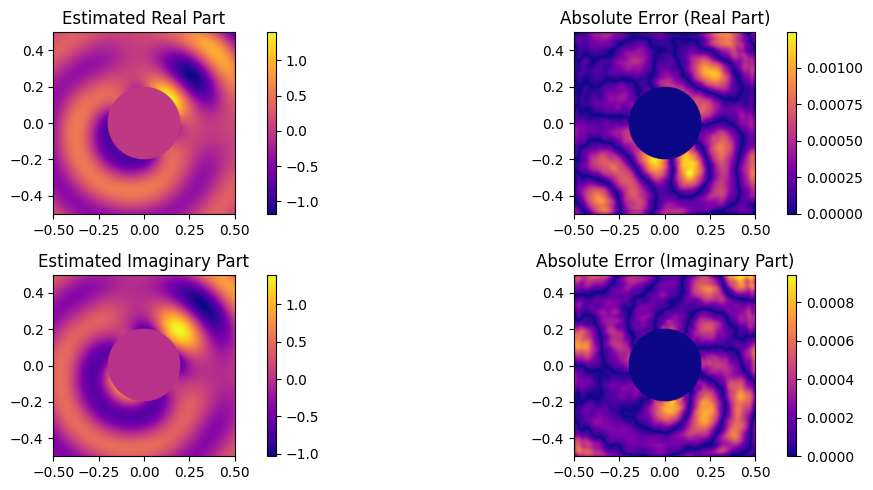

In [ ]:
# Loading and evaluating reference model
config['rff'] = 256      # RFF setup for current model on github. Baseline is 512
reference_model = init_model_from_conf(config).to(device)
print('Loading weights for reference model')
reference_model.load_state_dict(torch.load(ref_filename))
print('Reference model loaded!')


#Define mesh parameters
config['shape'] = config.get('shape', 'circle')
mesh_param = config['mesh_param']

#Can be adapted with a custom shape
if config['shape'] == 'circle':
    polygon = generate_circle(radius=mesh_param['r'], center=mesh_param['center'], num_points=2000)
    print('Reference model performance :')
    evaluate_circle_estimation(reference_model, config, mesh_param['r'], display = True)

else:
    raise ValueError('Wrong config, please verify or retrain a model')


## Loading different models for comparison with PHISK

In [ ]:
# Load LoRA Interpolation for comparison with PHISK
lora_interp = load_interpolated_model(reference_model, lora_dir, config, T = 0.1)

Loading LoRA ensemble from checkpoints/2D/lora/
Found 8 LoRA weight files
Loading +1.0+0.0.pth
Debug: LoRA state structure:
net.0: dict with 3 keys
  lora_A: tensor torch.Size([12, 512])
  lora_B: tensor torch.Size([64, 12])
  alpha: <class 'float'> = 1.0
net.2: dict with 3 keys
  lora_A: tensor torch.Size([12, 64])
  lora_B: tensor torch.Size([64, 12])
  alpha: <class 'float'> = 1.0
net.4: dict with 3 keys
  lora_A: tensor torch.Size([12, 64])
  lora_B: tensor torch.Size([64, 12])
  alpha: <class 'float'> = 1.0
net.6: dict with 3 keys
  lora_A: tensor torch.Size([12, 64])
  lora_B: tensor torch.Size([2, 12])
  alpha: <class 'float'> = 1.0
  Direction: [1. 0.]
Loading -1.8369701465288538e-16-1.0.pth
  Direction: [-1.8369701e-16 -1.0000000e+00]
Loading -0.7071068286895752-0.7071068286895752.pth
  Direction: [-0.7071068 -0.7071068]
Loading +0.7071068286895752+0.7071068286895752.pth
  Direction: [0.7071068 0.7071068]
Loading +0.7071068286895752-0.7071068286895752.pth
  Direction: [ 0.7071

In [ ]:
# Loading PHISK
config['lora_train'] = False

print(f'Loading PHISK')
phisk_model = load_directional_model(
reference_network=reference_model,
checkpoint_path=phisk_filename,
config=config,
hconfig=hconfig
)

print(f'Done!')

Loading PHISK
Incoming wave mode : plane
Loading hypernetwork checkpoint from checkpoints/2D/phisk/rff.pth
dict_keys(['interpolation_state', 'hypernetwork_state', 'fourier_features_B', 'lora_directions', 'param_shapes', 'lora_states'])
Successfully loaded hypernetwork with:
  - 8 LoRA directions
  - 10776 total parameters
  - Attention mechanism and hypernetwork states restored
Done!


In [ ]:
# Loading conditioned model e.g., a reference model with 4 input : coordinate + incoming wave direction
print(f'Loading Conditional Model')
conditioned_model = init_conditioned_model(config).to(device)
state_dict = torch.load(f'checkpoints/2D/conditioned/{model_name}.pth')  # ✅ load checkpoint
conditioned_model.load_state_dict(state_dict)

Loading Conditional Model


<All keys matched successfully>

## Evaluation on different direction

In [ ]:
def nmse(prediction, ground_truth):
    """
    Compute Normalized Mean Squared Error (NMSE).

    Parameters:
        y_true (array-like): True values
        y_pred (array-like): Predicted values

    Returns:
        float: NMSE value
    """
    mse = torch.mean((prediction[:, 0] - ground_truth[:, 0]) ** 2 + (prediction[:, 1] - ground_truth[:, 1]) ** 2)
    variance = torch.mean((ground_truth - torch.mean(ground_truth)) ** 2)
    target_square = torch.mean(ground_truth[:,0]**2 + torch.mean(ground_truth[:,1]**2))

    if variance == 0:
        return torch.tensor(float('inf')) if mse != 0 else torch.tensor(0.0)

    return 10*torch.log10(mse / target_square)

def cosine_similarity(predictions, targets):
    predictions = predictions.view(predictions.shape[0], -1)
    targets = targets.view(targets.shape[0], -1)
    cos_sim = F.cosine_similarity(predictions, targets, dim=0)
    return cos_sim


def nmse_plot(prediction, ground_truth):
    """
    Compute Normalized Mean Squared Error (NMSE).

    Parameters:
        y_true (array-like): True values
        y_pred (array-like): Predicted values

    Returns:
        float: NMSE value
    """
    eps = 1e-6
    mse = (prediction - ground_truth) ** 2
    target_square = ground_truth**2 + eps
    return 10*torch.log10(mse / target_square)

L = config['L']
config['res'] = 128
res = config['res']
R = config['mesh_param']['r']
center = torch.tensor(config['mesh_param']['center'], dtype = torch.double, device = config['device'])
x_grid = generate_grid(L, res, 2, device=phisk_model.device)
mask = (x_grid[:,0]-center[0])**2 + (x_grid[:,1]-center[1])**2 > R**2
print('mask shape :' ,mask.shape)

# Generate 50 evenly spread directions
angles = np.linspace(0, 2*np.pi, 30 , endpoint=False)
directions = torch.stack([torch.cos(torch.tensor(angles)), torch.sin(torch.tensor(angles))], dim=1).to(device).to(torch.float)

# Initialize score accumulators
ref_nmse_scores = []
ref_cosine_scores = []
conditioned_nmse_scores = []
conditioned_cosine_scores = []
lora_nmse_scores = []
lora_cosine_scores = []
phisk_nmse_scores = []
phisk_cosine_scores = []

k = 2 * np.pi * config['frequency'] / config['celerity'] # wavenumber

phisk_model.trainer.base_network = reference_model

with torch.no_grad():
    for i, direction in enumerate(directions):
        # print(i)
        # Normalize and reshape direction
        direction = direction.unsqueeze(1)
        direction = direction / torch.linalg.norm(direction)
        config['direction'] = direction

        # Generate target
        target = torch.zeros((res**2,2), device = config['device'], dtype = torch.double)
        target[mask,:] = sound_hard_circle(config, x_grid[mask,:] - center, R, center.cpu().numpy())

        # Reference model
        reference_model.eval()
        ref_pred = torch.zeros((res**2,2), device = config['device'])
        ref_pred[mask,:] = reference_model(x_grid[mask,:])
        ref_nmse_scores.append(nmse(ref_pred, target).cpu().item())
        ref_cosine_scores.append(torch.mean(1-cosine_similarity(ref_pred, target)).cpu().item())

        # conditioned model
        conditioned_model.eval()
        conditioned_pred = torch.zeros((res**2,2), device = config['device'])
        conditioned_pred[mask,:] = conditioned_model(x_grid[mask,:], direction = direction.T[0])
        conditioned_nmse_scores.append(nmse(conditioned_pred, target).cpu().item())
        conditioned_cosine_scores.append(torch.mean(1-cosine_similarity(conditioned_pred, target)).cpu().item())

        # LoRA interpolation model
        lora_interp.eval()
        lora_pred = torch.zeros((res**2,2), device = config['device'])
        lora_pred[mask,:] = lora_interp(x_grid[mask, :], direction = direction.T[0])
        lora_nmse_scores.append(nmse(lora_pred, target).cpu().item())
        lora_cosine_scores.append(torch.mean(1-cosine_similarity(lora_pred, target)).cpu().item())

        # PHISK model
        phisk_model.eval()
        pred = torch.zeros((res**2,2), device = config['device'])
        pred[mask,:] = phisk_model(x_grid[mask, :], direction = direction.T[0])
        phisk_nmse_scores.append(nmse(pred, target).cpu().item())
        phisk_cosine_scores.append(torch.mean(1-cosine_similarity(pred, target)).cpu().item())

# Print average scores
print('Reference Model (just to compare with a flat one directional approximation):')
print(f'  Average NMSE: {np.mean(ref_nmse_scores):.6f} ± {np.std(ref_nmse_scores):.6f}')
print(f'  Average 1-Cosine Similarity: {np.mean(ref_cosine_scores):.6f} ± {np.std(ref_cosine_scores):.6f}')

print('\nconditioned Model:')
print(f'  Average NMSE: {np.mean(conditioned_nmse_scores):.6f} ± {np.std(conditioned_nmse_scores):.6f}')
print(f'  Average 1-Cosine Similarity: {np.mean(conditioned_cosine_scores):.6f} ± {np.std(conditioned_cosine_scores):.6f}')

print('\nLoRA Interpolation Model:')
print(f'  Average NMSE: {np.mean(lora_nmse_scores):.6f} ± {np.std(lora_nmse_scores):.6f}')
print(f'  Average 1-Cosine Similarity: {np.mean(lora_cosine_scores):.6f} ± {np.std(lora_cosine_scores):.6f}')

print('\nPhisk Model:')
print(f'  Average NMSE: {np.mean(phisk_nmse_scores):.6f} ± {np.std(phisk_nmse_scores):.6f}')
print(f'  Average 1-Cosine Similarity: {np.mean(phisk_cosine_scores):.6f} ± {np.std(phisk_cosine_scores):.6f}')

# NOTE : Here 8 LoRA directions are used instead of 4 in the original paper

mask shape : torch.Size([16384])
Reference Model (just to compare with a flat one directional approximation):
  Average NMSE: 1.676487 ± 5.215182
  Average 1-Cosine Similarity: 0.991245 ± 0.482885

conditioned Model:
  Average NMSE: -11.896763 ± 1.182746
  Average 1-Cosine Similarity: 0.029948 ± 0.009432

LoRA Interpolation Model:
  Average NMSE: -4.493821 ± 4.970648
  Average 1-Cosine Similarity: 0.338770 ± 0.320582

Phisk Model:
  Average NMSE: -20.584781 ± 1.596919
  Average 1-Cosine Similarity: 0.003369 ± 0.000887


## Visualisation of PHISK performances

mask shape: torch.Size([16384])
Direction 1/90: 0.0°
  NMSE Real: -21.8435 ± 35.1445
  NMSE Imag: -18.7195 ± 35.9616
  Cosine Similarity Real: 0.0027, Imag: 0.0054
Direction 2/90: 4.0°
  NMSE Real: -21.8410 ± 35.2922
  NMSE Imag: -18.6436 ± 36.0512
  Cosine Similarity Real: 0.0028, Imag: 0.0056
Direction 3/90: 8.1°
  NMSE Real: -22.1099 ± 35.2434
  NMSE Imag: -18.7647 ± 36.0443
  Cosine Similarity Real: 0.0027, Imag: 0.0055
Direction 4/90: 12.1°
  NMSE Real: -22.6420 ± 35.0624
  NMSE Imag: -19.1789 ± 35.9158
  Cosine Similarity Real: 0.0024, Imag: 0.0050
Direction 5/90: 16.2°
  NMSE Real: -23.2425 ± 34.8432
  NMSE Imag: -19.6674 ± 35.6990
  Cosine Similarity Real: 0.0020, Imag: 0.0045
Direction 6/90: 20.2°
  NMSE Real: -23.6073 ± 34.6687
  NMSE Imag: -19.9359 ± 35.5937
  Cosine Similarity Real: 0.0018, Imag: 0.0043
Direction 7/90: 24.3°
  NMSE Real: -23.8412 ± 34.4549
  NMSE Imag: -20.1552 ± 35.4557
  Cosine Similarity Real: 0.0017, Imag: 0.0040
Direction 8/90: 28.3°
  NMSE Real: -24.1

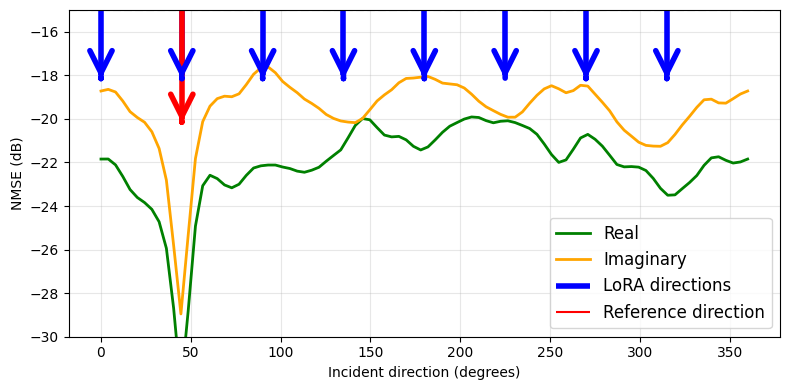


SUMMARY STATISTICS
Circle Radius: 0.2
Number of directions tested: 90
Angle range: 0.0° to 360.0°

NMSE Statistics:
  Real - Mean: -2.21e+01, Std: 1.92e+00
  Imag - Mean: -1.96e+01, Std: 1.67e+00

Cosine Similarity Statistics:
  Real - Mean: 0.0022, Std: 0.0006
  Imag - Mean: 0.0046, Std: 0.0013

Best Performance:
  Real: 44.5° (NMSE: -3.23e+01)
  Imag: 44.5° (NMSE: -2.90e+01)

Worst Performance:
  Real: 206.3° (NMSE: -1.99e+01)
  Imag: 93.0° (NMSE: -1.76e+01)


In [ ]:
def create_evaluation_plots(results):
    """Create comprehensive evaluation plots"""
    angles = results['angles']
    nmse_real = results['nmse_real']
    nmse_imag = results['nmse_imag']
    cos_sim_real = results['cos_sim_real']
    cos_sim_imag = results['cos_sim_imag']
    R = results['radius']
    #fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    fig, (ax1) = plt.subplots(1, 1, figsize=(8, 4))
    # Plot 1: NMSE in dB (your values are already in dB)
    angle_list = np.array([0, 45, 90, 135 , 180, 225, 270, 315]) #* np.pi / 180 #, 270])
    val_list = [-18 for x in angle_list]
    ax1.plot(angles, nmse_real, label='Real', color = 'green',linewidth=2)
    ax1.plot(angles, nmse_imag, label='Imaginary', color = 'orange', linewidth=2)

    baseline = -15

    # Plot stems manually and capture the line object for legend
    stem_lines = []
    i = 0
    for xi, yi in zip(angle_list,val_list):
        if i==0:
            line = ax1.vlines(xi, baseline, yi, color='blue', label = 'LoRA directions', linewidth = 4)
        else:
            line = ax1.vlines(xi, baseline, yi, color='blue', linewidth = 4)
        ax1.annotate('', xy=(xi, yi), xytext=(xi, yi - .3),  # adjust 0.3 to control arrow size
                    arrowprops=dict(arrowstyle='<-', color='blue', mutation_scale=40, linewidth = 4))
        stem_lines.append(line)
        i += 1
    xi = 45
    yi = val_list[0]-2
    line = ax1.vlines(xi, baseline, yi, color='red', label ='Reference direction')
    ax1.vlines(xi, baseline, yi, color='red', linewidth = 4)

    # Draw arrowhead at the top of the stem
    ax1.annotate('', xy=(xi, yi), xytext=(xi, yi - .3),  # adjust 0.3 to control arrow size
                arrowprops=dict(arrowstyle='<-', color='red', mutation_scale=40, linewidth = 4))
    stem_lines.append(line)
    ax1.set_ylim([-30., baseline])
    # Draw baseline
    ax1.axhline(baseline, color='gray', linestyle='--')

    # Create a custom legend handle to represent the stems
    from matplotlib.lines import Line2D
    #legend_handle = Line2D([0], [0], color='blue', marker='o', linestyle='-', markersize=6)
    #ax1.legend([legend_handle], ['My Stem Plot'])

    ax1.set_xlabel('Incident direction (degrees)')
    ax1.set_ylabel('NMSE (dB)')
    ax1.legend(loc='lower right', fontsize=12)
    #ax1.legend()
    ax1.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("nmse_vs_angle_plot.pdf", format='pdf', bbox_inches='tight')
    plt.show()

    # Additional summary statistics
    print("\n" + "="*50)
    print("SUMMARY STATISTICS")
    print("="*50)
    print(f"Circle Radius: {R}")
    print(f"Number of directions tested: {len(angles)}")
    print(f"Angle range: {min(angles):.1f}° to {max(angles):.1f}°")
    print("\nNMSE Statistics:")
    print(f"  Real - Mean: {np.mean(nmse_real):.2e}, Std: {np.std(nmse_real):.2e}")
    print(f"  Imag - Mean: {np.mean(nmse_imag):.2e}, Std: {np.std(nmse_imag):.2e}")
    print("\nCosine Similarity Statistics:")
    print(f"  Real - Mean: {np.mean(cos_sim_real):.4f}, Std: {np.std(cos_sim_real):.4f}")
    print(f"  Imag - Mean: {np.mean(cos_sim_imag):.4f}, Std: {np.std(cos_sim_imag):.4f}")

    # Find best and worst performing directions
    best_real_idx = np.argmin(nmse_real)
    worst_real_idx = np.argmax(nmse_real)
    best_imag_idx = np.argmin(nmse_imag)
    worst_imag_idx = np.argmax(nmse_imag)

    print(f"\nBest Performance:")
    print(f"  Real: {angles[best_real_idx]:.1f}° (NMSE: {nmse_real[best_real_idx]:.2e})")
    print(f"  Imag: {angles[best_imag_idx]:.1f}° (NMSE: {nmse_imag[best_imag_idx]:.2e})")
    print(f"\nWorst Performance:")
    print(f"  Real: {angles[worst_real_idx]:.1f}° (NMSE: {nmse_real[worst_real_idx]:.2e})")
    print(f"  Imag: {angles[worst_imag_idx]:.1f}° (NMSE: {nmse_imag[worst_imag_idx]:.2e})")

config['res'] = 128  # Faster evaluation
results = evaluate_circle_estimation_direction(phisk_model, config, R, plot = False, num_dir = 90)
create_evaluation_plots(results)

## Visualization comparison for one direction

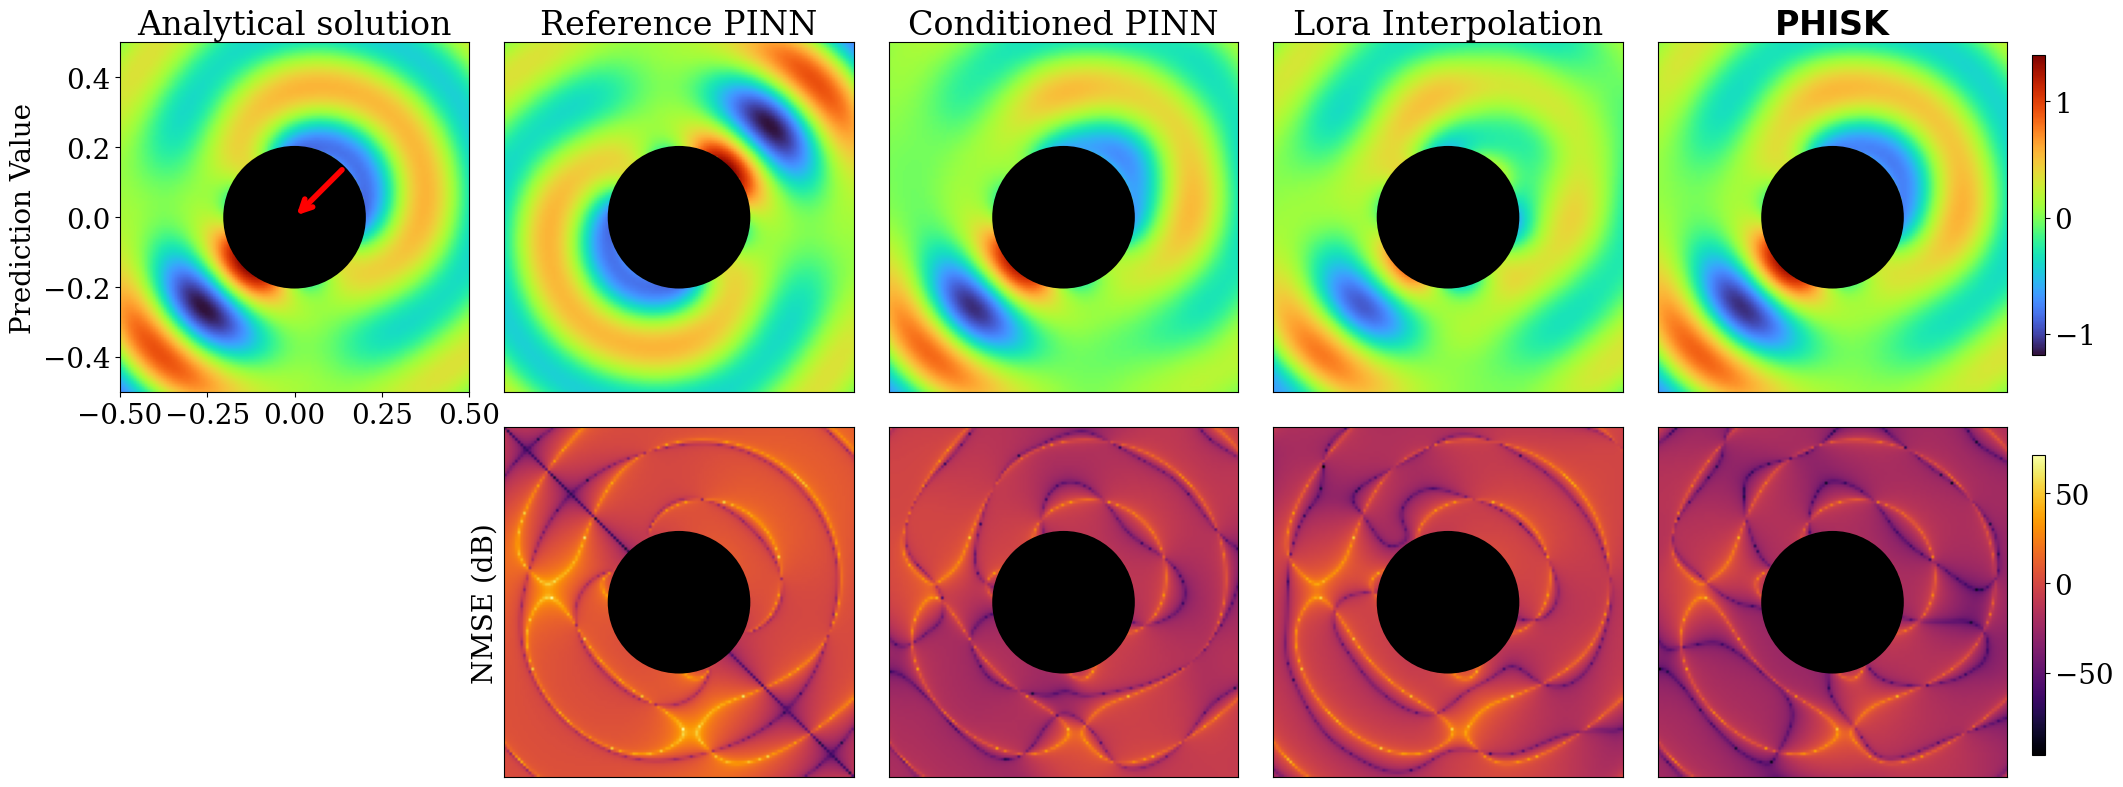

In [ ]:
# Visualize network results compared to reference direction
def create_obstacle_patch(polygon, shape_type="polygon"):
    return Polygon(polygon, closed=True, color='black', alpha=0.4)


direction = torch.tensor([-.5, -.5], device = device).unsqueeze(1) # Select your direction
direction =  direction / torch.linalg.norm(direction)
config['direction'] = direction


plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 20  # Base font size
plt.rcParams['axes.titlesize'] = 24  # Title font size
plt.rcParams['axes.labelsize'] = 20  # Axis label font size

with torch.no_grad():
    # Generate target data
    target = torch.zeros((res**2,2), device = config['device'], dtype = torch.double)
    target[mask,:] = sound_hard_circle(config, x_grid[mask,:] - center, R, center.cpu().numpy())

    # Reference model prediction
    reference_model.eval()
    ref_pred = torch.zeros((res**2,2), device = config['device'])
    ref_pred[mask,:] = reference_model(x_grid[mask,:])
    nmse_ref = nmse_plot(ref_pred[:,0], target[:,0])

    # conditioned model prediction
    conditioned_model.eval()
    conditioned_pred = torch.zeros((res**2,2), device = config['device'])
    conditioned_pred[mask,:] = conditioned_model(x_grid[mask,:], direction = direction.T[0])
    nmse_conditioned = nmse_plot(conditioned_pred[:,0], target[:,0])

    # Lora model prediction
    lora_interp.eval()
    lora_pred = torch.zeros((res**2,2), device = config['device'])
    lora_pred[mask,:] = lora_interp(x_grid[mask, :], direction = direction.T[0])
    nmse_lora = nmse_plot(lora_pred[:,0], target[:,0])

    # phisk model prediction
    phisk_model.eval()
    phisk_pred = torch.zeros((res**2,2), device = config['device'])
    phisk_pred[mask,:] = phisk_model(x_grid[mask, :], direction = direction.T[0])
    nmse_phisk = nmse_plot(phisk_pred[:,0], target[:,0])

# Convert to numpy and reshape for plotting
target_np = target.cpu().numpy().reshape(res, res, 2)[:, :, 0]
ref_pred_np = ref_pred.cpu().numpy().reshape(res, res, 2)[:, :, 0]
conditioned_pred_np = conditioned_pred.cpu().numpy().reshape(res, res, 2)[:, :, 0]
lora_pred_np = lora_pred.cpu().numpy().reshape(res, res, 2)[:, :, 0]
phisk_pred_np = phisk_pred.cpu().numpy().reshape(res, res, 2)[:, :, 0]

# Calculate NMSE plots (relative error plots)
eps = 1e-12
def calculate_nmse_plot(pred, target):
    mse = (pred - target) ** 2 + eps
    target_square = target**2 + eps
    return 10 * np.log10(mse / target_square)

# NMSE error plots for each model
nmse_ref_plot = calculate_nmse_plot(ref_pred_np, target_np)
nmse_conditioned_plot = calculate_nmse_plot(conditioned_pred_np, target_np)
nmse_lora_plot = calculate_nmse_plot(lora_pred_np, target_np)
nmse_phisk_plot = calculate_nmse_plot(phisk_pred_np, target_np)

# Average NMSE values for titles
#nmse_ref_avg = nmse_ref.item()
#nmse_conditioned_avg = nmse_conditioned.item()
#nmse_lora_avg = nmse_lora.item()
#nmse_phisk_avg = nmse_phisk.item()

model_names = ['Analytical solution', 'Reference PINN', 'Conditioned PINN', 'Lora Interpolation', r'$\mathbf{PHISK}$']

# Top row: Raw predictions, Bottom row: NMSE error plots
predictions_top = [target_np, ref_pred_np, conditioned_pred_np, lora_pred_np, phisk_pred_np]
nmse_plots_bottom = [target_np-target_np, nmse_ref_plot, nmse_conditioned_plot, nmse_lora_plot, nmse_phisk_plot]

# Create obstacle patches (adjust these coordinates based on your actual obstacles)
polygons = []
# Add circle obstacle if needed
circle = plt.Circle(center.cpu().numpy(), R, fill=False, edgecolor='black', linewidth=2)

# Calculate global min/max for consistent colormaps
# Top row: predictions
all_real_top = [pred for pred in predictions_top]
real_min_top = min([pred.min() for pred in all_real_top])
real_max_top = max([pred.max() for pred in all_real_top])

# Bottom row: NMSE plots (skip target for NMSE calculation)
nmse_real_plots = [plot for plot in nmse_plots_bottom[1:]]  # Skip target
nmse_real_min = min([plot.min() for plot in nmse_real_plots])
nmse_real_max = max([plot.max() for plot in nmse_real_plots])

# --- Plot Setup ---
fig, axs = plt.subplots(2, 5, figsize=(25, 10), constrained_layout=False)
plt.subplots_adjust(right=0.88, hspace=0., wspace=0.1)

# --- Top row: Raw predictions (Real parts) ---
for i in range(5):
    im_top = axs[0, i].imshow(predictions_top[i], extent=[-L, L, -L, L],
                             origin='lower', cmap='turbo', vmin=real_min_top, vmax=real_max_top)
    if i == 0:
        axs[0, i].set_title(f'{model_names[i]}')
        axs[0, i].annotate('', xy=(0., 0.), xytext=(-R * direction[0][0].cpu().numpy(), -R * direction[1][0].cpu().numpy()),
                          arrowprops=dict(arrowstyle='->', color='red', lw=4))
    else:
        axs[0, i].set_title(f'{model_names[i]}') # Real (Avg NMSE: {avg_nmse_values[i]:.2f} dB)')
    if i!=0:
        axs[0, i].set_xticks([])
        axs[0, i].set_yticks([])

    # Add circle obstacle
    circle_patch = plt.Circle(center.cpu().numpy(), R, fill=True, facecolor='black',
                             edgecolor='black', linewidth=2)
    axs[0, i].add_patch(circle_patch)

# --- Bottom row: NMSE error plots (Real parts) ---

    # For predictions, show NMSE error plot
    if i == 0:
        im_bottom = axs[1, i].imshow(np.full((res, res), np.nan), extent=[-L, L, -L, L],
                                    origin='lower', cmap='inferno', vmin=nmse_real_min, vmax=nmse_real_max)
        for spine in axs[1, i].spines.values():
            spine.set_visible(False)
    else:
        im_bottom = axs[1, i].imshow(nmse_plots_bottom[i], extent=[-L, L, -L, L],
                                    origin='lower', cmap='inferno', vmin=nmse_real_min, vmax=nmse_real_max)
        #axs[1, i].set_title(f'{model_names[i]} NMSE Real')

    axs[1, i].set_xticks([])
    axs[1, i].set_yticks([])

    # Add circle obstacle
    if i!=0:
        circle_patch = plt.Circle(center.cpu().numpy(), R, fill=True, facecolor='black',
                                edgecolor='black', linewidth=2)
        axs[1, i].add_patch(circle_patch)

axs[0,0].set_ylabel('Prediction Value')
axs[1,1].set_ylabel('NMSE (dB)')
# --- Colorbars ---

cbar_ax_top = fig.add_axes([0.89, 0.55, 0.005, 0.3])
fig.colorbar(im_top, cax=cbar_ax_top)

cbar_ax_bottom = fig.add_axes([0.89, 0.15, 0.005, 0.3])
fig.colorbar(im_bottom, cax=cbar_ax_bottom)
plt.savefig("nmse_model.pdf", format='pdf', bbox_inches='tight')
plt.show()
